In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from HandLandMarks import HandLandmarksHandleImage
import joblib
import glob
import cv2
pd.set_option('display.max_rows', 10)
pd.set_option('display.max_columns', 6)

In [63]:
dataset_path = "./Dataset/data.csv"

In [143]:
df = pd.read_csv(dataset_path)

In [127]:
df

,Unnamed: 0,x1,y1,...,y21,z21,label
0,0,0.633498,0.428754,...,0.308255,-0.004322,click
1,1,0.638007,0.423937,...,0.313696,0.000030,click
2,2,0.639885,0.429533,...,0.320722,-0.001227,click
3,3,0.639866,0.425877,...,0.318917,-0.000745,click
4,4,0.638429,0.426757,...,0.318095,-0.000619,click
...,...,...,...,...,...,...,...
795,195,0.397263,0.234096,...,0.423651,-0.010854,scroll_down
796,196,0.401232,0.235158,...,0.422854,-0.015469,scroll_down
797,197,0.401448,0.236129,...,0.421505,-0.018438,scroll_down
798,198,0.393740,0.235885,...,0.422933,-0.017353,scroll_down


In [144]:
df = df.drop(columns='Unnamed: 0')
df

,x1,y1,z1,...,y21,z21,label
0,0.633498,0.428754,-4.855502e-07,...,0.308255,-0.004322,click
1,0.638007,0.423937,-4.511978e-07,...,0.313696,0.000030,click
2,0.639885,0.429533,-4.316552e-07,...,0.320722,-0.001227,click
3,0.639866,0.425877,-4.401641e-07,...,0.318917,-0.000745,click
4,0.638429,0.426757,-4.355380e-07,...,0.318095,-0.000619,click
...,...,...,...,...,...,...,...
795,0.397263,0.234096,5.542514e-07,...,0.423651,-0.010854,scroll_down
796,0.401232,0.235158,5.601350e-07,...,0.422854,-0.015469,scroll_down
797,0.401448,0.236129,5.657998e-07,...,0.421505,-0.018438,scroll_down
798,0.393740,0.235885,5.950544e-07,...,0.422933,-0.017353,scroll_down


In [54]:
df.groupby('label').describe()

x1                      ...       z21                    
             count      mean       std  ...       50%       75%       max
label                                   ...                              
click        200.0  0.541776  0.117875  ... -0.004903 -0.002116  0.013212
release      200.0  0.471153  0.158639  ... -0.058666 -0.049225 -0.039152
scroll_down  200.0  0.507942  0.119793  ... -0.018325 -0.008214  0.055279
scroll_up    200.0  0.490927  0.142980  ... -0.092901 -0.084023 -0.058192

[4 rows x 504 columns]

In [55]:
def draw_first_item(label):
    plt.figure(figsize=(5,6))
    ax = plt.gca()
    a0 = df.groupby('label').get_group(label).iloc[0].drop(index='label')
    arr = np.zeros((128 , 128))
    for i in range(0,63,3):
        x = int(a0.values[i] * 128)
        y = int(a0.values[i + 1] * 128)
        arr[y][x] = 255

    plt.imshow(arr)
    plt.title(f'Image for {label}')
    ax.spines[['top','right','bottom','left']].set_visible(False)
    plt.xticks([],[])
    plt.yticks([],[])
    plt.show()

In [61]:
labels = df['label'].value_counts().index.array

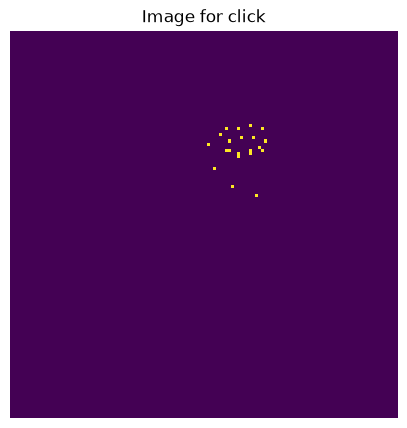

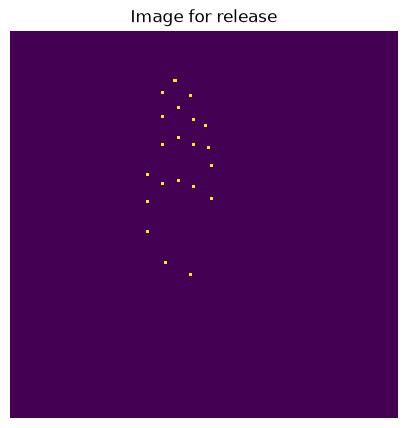

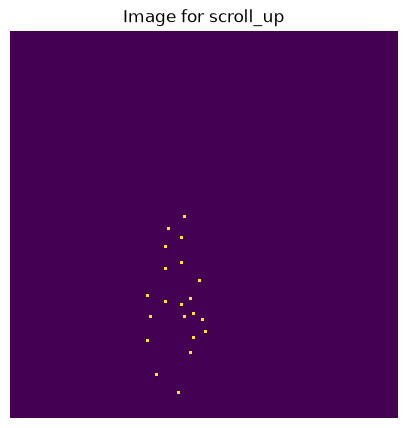

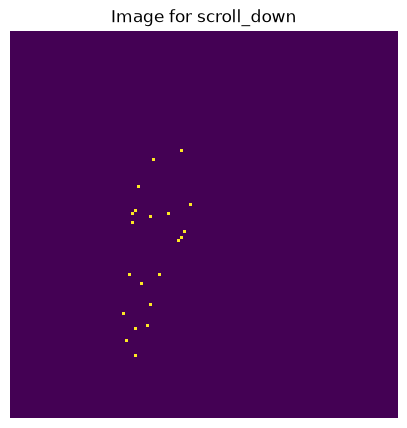

In [145]:
for label in labels:
    draw_first_item(label)

#### Basing on the output Our Data is good

* click -> close_hand
* release -> open_hand
* scroll_up -> two_finger_up
* scrol_down -> two_finger_down

Now Let's prepare our data for training

First let's map our label to indexes

In [146]:
mapped_labels = {label:idx for (idx,label) in enumerate(labels)}
mapped_labels

{'click': 0, 'release': 1, 'scroll_up': 2, 'scroll_down': 3}

In [147]:
df['label'] = df['label'].map(mapped_labels)
df

,x1,y1,z1,...,y21,z21,label
0,0.633498,0.428754,-4.855502e-07,...,0.308255,-0.004322,0
1,0.638007,0.423937,-4.511978e-07,...,0.313696,0.000030,0
2,0.639885,0.429533,-4.316552e-07,...,0.320722,-0.001227,0
3,0.639866,0.425877,-4.401641e-07,...,0.318917,-0.000745,0
4,0.638429,0.426757,-4.355380e-07,...,0.318095,-0.000619,0
...,...,...,...,...,...,...,...
795,0.397263,0.234096,5.542514e-07,...,0.423651,-0.010854,3
796,0.401232,0.235158,5.601350e-07,...,0.422854,-0.015469,3
797,0.401448,0.236129,5.657998e-07,...,0.421505,-0.018438,3
798,0.393740,0.235885,5.950544e-07,...,0.422933,-0.017353,3


In [148]:
y = df['label']
X = df.drop(columns='label')

In [150]:
X

,x1,y1,z1,...,x21,y21,z21
0,0.633498,0.428754,-4.855502e-07,...,0.650834,0.308255,-0.004322
1,0.638007,0.423937,-4.511978e-07,...,0.651221,0.313696,0.000030
2,0.639885,0.429533,-4.316552e-07,...,0.655961,0.320722,-0.001227
3,0.639866,0.425877,-4.401641e-07,...,0.656558,0.318917,-0.000745
4,0.638429,0.426757,-4.355380e-07,...,0.656425,0.318095,-0.000619
...,...,...,...,...,...,...,...
795,0.397263,0.234096,5.542514e-07,...,0.356497,0.423651,-0.010854
796,0.401232,0.235158,5.601350e-07,...,0.353612,0.422854,-0.015469
797,0.401448,0.236129,5.657998e-07,...,0.353933,0.421505,-0.018438
798,0.393740,0.235885,5.950544e-07,...,0.349605,0.422933,-0.017353


In [149]:
y

0      0
1      0
2      0
3      0
4      0
      ..
795    3
796    3
797    3
798    3
799    3
Name: label, Length: 800, dtype: int64

In [151]:
X_train, X_test, y_train, y_test = train_test_split(
    X,  
    y,         
    test_size=0.2,  
    random_state=88,
    stratify=y
)

In [152]:
y_train.value_counts()

label
0    160
2    160
1    160
3    160
Name: count, dtype: int64

In [153]:
y_test.value_counts()

label
2    40
0    40
3    40
1    40
Name: count, dtype: int64

In [154]:
y_train

98     0
454    2
348    1
343    1
700    3
      ..
741    3
675    3
277    1
785    3
230    1
Name: label, Length: 640, dtype: int64

In [137]:
y_test

666    scroll_down
601    scroll_down
779    scroll_down
177          click
437      scroll_up
          ...     
298        release
458      scroll_up
368        release
756    scroll_down
149          click
Name: label, Length: 160, dtype: str

In [155]:
model = Pipeline(
    [
        ('scaler', StandardScaler()),
        ('regressor', LogisticRegression(max_iter=500))
    ]
)

In [156]:
model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](4,)","[0,1,2,3]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](63,)","['x1','y1','z1',...,'x21','y21','z21']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,63
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [157]:
predictions = model.predict(X_test)

In [158]:
score = model.score(X_test, y_test) 
corrected = (predictions == y_test).sum()
print(f'corrected predictions : {corrected}/{y_test.shape[0]}')
print(f"Model R^2 Score: {score:.4f}")

corrected predictions : 160/160
Model R^2 Score: 1.0000


Now Let's import another dataset for the validation

In [159]:
validation_path = './Dataset/validation.csv'

df_val = pd.read_csv(validation_path)

In [160]:
df_val

,Unnamed: 0,x1,y1,...,y21,z21,label
0,0,0.543662,0.362398,...,0.238791,-0.006599,click
1,1,0.543662,0.362398,...,0.238791,-0.006599,click
2,2,0.538934,0.363630,...,0.241263,-0.007781,click
3,3,0.538934,0.363630,...,0.241263,-0.007781,click
4,4,0.538934,0.363630,...,0.241263,-0.007781,click
...,...,...,...,...,...,...,...
155,35,0.451658,0.467846,...,0.736327,0.016810,scroll_down
156,36,0.448396,0.468912,...,0.844986,0.029794,scroll_down
157,37,0.444355,0.466944,...,0.705449,0.011328,scroll_down
158,38,0.444355,0.466944,...,0.705449,0.011328,scroll_down


In [161]:
df_val = df_val.drop(columns='Unnamed: 0')

In [162]:
df_val



,x1,y1,z1,...,y21,z21,label
0,0.543662,0.362398,-5.260860e-07,...,0.238791,-0.006599,click
1,0.543662,0.362398,-5.260860e-07,...,0.238791,-0.006599,click
2,0.538934,0.363630,-5.121996e-07,...,0.241263,-0.007781,click
3,0.538934,0.363630,-5.121996e-07,...,0.241263,-0.007781,click
4,0.538934,0.363630,-5.121996e-07,...,0.241263,-0.007781,click
...,...,...,...,...,...,...,...
155,0.451658,0.467846,4.567116e-07,...,0.736327,0.016810,scroll_down
156,0.448396,0.468912,4.106450e-07,...,0.844986,0.029794,scroll_down
157,0.444355,0.466944,4.993931e-07,...,0.705449,0.011328,scroll_down
158,0.444355,0.466944,4.993931e-07,...,0.705449,0.011328,scroll_down


In [163]:
indices = np.arange(df_val.shape[0])

In [164]:
np.random.shuffle(indices)

In [165]:
indices

array([ 82, 112, 136, 122, 157, 103,  25,  85, 144, 114,  35,  46, 130,
         4, 104,  87,  69,  91,  11,   0,  42, 137, 149,  44,  74,  72,
       152,  43, 156,  73, 158,  88,  39,   2,  65,  92,  93,  66, 134,
       118,  68,  10,  23, 116,   6, 105, 120,  58, 141, 139, 159,  20,
       148,  29, 126, 146,  48,  36,  60,  32,  54, 153,  94,  40, 108,
       113,  49,  45,  84,  90,  62,  80,  77,  76,  98,  83,  99,  30,
        75,  59,  89,  34,   3, 117,  21, 127,  37,   9, 138,   1,  31,
       107,  95,  71,  56,  63, 133,  57, 109, 150,  27,  14, 106, 124,
        64, 155,  33,  16, 145,  55,  70,  38, 111, 131,  19,  53, 100,
       102,  12, 101,  81,  61,  18, 132,  67, 147, 129, 140, 115,  79,
        24, 142, 125,  86,  78,  47,  13,  17, 128,  97,   8,  50,   5,
        52, 135,  51, 110,  28, 143,  22,  41,   7,  15, 119, 121,  96,
       123, 154,  26, 151])

In [166]:
df_val = df_val.iloc[indices]
df_val

,x1,y1,z1,...,y21,z21,label
82,0.240198,0.551094,3.265258e-07,...,0.256452,-0.047267,scroll_up
112,0.359593,0.715220,7.188229e-07,...,0.608397,-0.111931,scroll_up
136,0.533180,0.281594,5.019122e-07,...,0.482659,-0.031692,scroll_down
122,0.482418,0.283672,-1.006989e-06,...,0.530665,-0.222676,scroll_down
157,0.444355,0.466944,4.993931e-07,...,0.705449,0.011328,scroll_down
...,...,...,...,...,...,...,...
96,0.514021,0.663076,5.237384e-07,...,0.560440,-0.118451,scroll_up
123,0.521181,0.292458,5.908532e-07,...,0.490872,-0.009499,scroll_down
154,0.451658,0.467846,4.567116e-07,...,0.736327,0.016810,scroll_down
26,0.500415,0.467529,-5.299532e-07,...,0.412057,-0.019791,click


In [167]:
df_val['label'] = df_val['label'].map(mapped_labels)

In [168]:
df_val

,x1,y1,z1,...,y21,z21,label
82,0.240198,0.551094,3.265258e-07,...,0.256452,-0.047267,2
112,0.359593,0.715220,7.188229e-07,...,0.608397,-0.111931,2
136,0.533180,0.281594,5.019122e-07,...,0.482659,-0.031692,3
122,0.482418,0.283672,-1.006989e-06,...,0.530665,-0.222676,3
157,0.444355,0.466944,4.993931e-07,...,0.705449,0.011328,3
...,...,...,...,...,...,...,...
96,0.514021,0.663076,5.237384e-07,...,0.560440,-0.118451,2
123,0.521181,0.292458,5.908532e-07,...,0.490872,-0.009499,3
154,0.451658,0.467846,4.567116e-07,...,0.736327,0.016810,3
26,0.500415,0.467529,-5.299532e-07,...,0.412057,-0.019791,0


In [169]:
y_val = df_val['label']
X_val = df_val.drop(columns='label')

In [170]:
X_val

,x1,y1,z1,...,x21,y21,z21
82,0.240198,0.551094,3.265258e-07,...,0.417270,0.256452,-0.047267
112,0.359593,0.715220,7.188229e-07,...,0.357038,0.608397,-0.111931
136,0.533180,0.281594,5.019122e-07,...,0.546084,0.482659,-0.031692
122,0.482418,0.283672,-1.006989e-06,...,0.543681,0.530665,-0.222676
157,0.444355,0.466944,4.993931e-07,...,0.449003,0.705449,0.011328
...,...,...,...,...,...,...,...
96,0.514021,0.663076,5.237384e-07,...,0.526364,0.560440,-0.118451
123,0.521181,0.292458,5.908532e-07,...,0.539706,0.490872,-0.009499
154,0.451658,0.467846,4.567116e-07,...,0.446460,0.736327,0.016810
26,0.500415,0.467529,-5.299532e-07,...,0.441336,0.412057,-0.019791


In [171]:
y_val

82     2
112    2
136    3
122    3
157    3
      ..
96     2
123    3
154    3
26     0
151    3
Name: label, Length: 160, dtype: int64

In [172]:
X_val.info()

<class 'pandas.DataFrame'>
Index: 160 entries, 82 to 151
Data columns (total 63 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      160 non-null    float64
 1   y1      160 non-null    float64
 2   z1      160 non-null    float64
 3   x2      160 non-null    float64
 4   y2      160 non-null    float64
 5   z2      160 non-null    float64
 6   x3      160 non-null    float64
 7   y3      160 non-null    float64
 8   z3      160 non-null    float64
 9   x4      160 non-null    float64
 10  y4      160 non-null    float64
 11  z4      160 non-null    float64
 12  x5      160 non-null    float64
 13  y5      160 non-null    float64
 14  z5      160 non-null    float64
 15  x6      160 non-null    float64
 16  y6      160 non-null    float64
 17  z6      160 non-null    float64
 18  x7      160 non-null    float64
 19  y7      160 non-null    float64
 20  z7      160 non-null    float64
 21  x8      160 non-null    float64
 22  y8      160 non-n

In [173]:
y_val.info()

<class 'pandas.Series'>
Index: 160 entries, 82 to 151
Series name: label
Non-Null Count  Dtype
--------------  -----
160 non-null    int64
dtypes: int64(1)
memory usage: 2.5 KB


##### Let's Begin validation

In [174]:
y_pred = model.predict(X_val)

score = model.score(X_val, y_val) 
corrected = (y_pred == y_val).sum()
print(f'corrected predictions : {corrected}/{y_val.shape[0]}')
print(f"Model R^2 Score: {score:.4f}")

corrected predictions : 131/160
Model R^2 Score: 0.8187


It's look like our model suffer predict some label correctly ,Let's identify them 

In [175]:
corrected_pred = y_val[y_val == y_pred]

In [176]:
corrected_pred = corrected_pred.value_counts()

In [177]:
corrected_pred

label
3    38
1    37
2    36
0    20
Name: count, dtype: int64

In [178]:
incorrected_pred = y_val[y_val != y_pred]

In [179]:
incorrected_pred = incorrected_pred.value_counts()

In [180]:
incorrected_pred

label
0    20
2     4
1     3
3     2
Name: count, dtype: int64

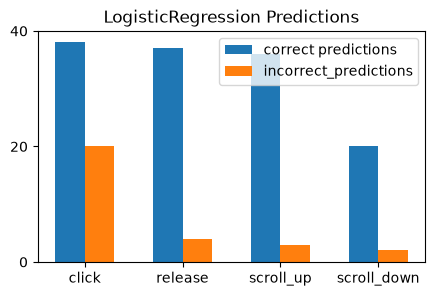

In [182]:
index_plot1 =np.arange(0,corrected_pred.shape[0])
index_plot2 =np.arange(0,incorrected_pred.shape[0])
width = 0.3
plt.figure(figsize=(5,3))
plt.bar(index_plot1 - width / 2,corrected_pred,width=0.3,label='correct predictions')
plt.bar(index_plot2 + width / 2,incorrected_pred,width=0.3,label='incorrect_predictions')
plt.title('LogisticRegression Predictions')
plt.yticks([0,20,40],['0','20','40'])
plt.xticks(index_plot,labels)
plt.legend()
plt.show()

Based on our graph we see that our model suffer to identify the click label

### Let's save our model and test it with some sample

##### Save Model

In [188]:
model_path = './resources/model.pl'

In [190]:
#joblib.dump(model,filename=model_path)

##### Load model

In [189]:
#model = joblib.load(model_path)

In [4]:
idx_labels = {0:"click",1:"release",2:"scroll_up",3:"scroll_down"}
idx_labels

{0: 'click', 1: 'release', 2: 'scroll_up', 3: 'scroll_down'}

In [183]:
landmarker = HandLandmarksHandleImage()

In [184]:
def draw_label(img,text,p1,p2):
    text_x = p1[0] + int((p2[0] - p1[0]) / 2)
    text_y = p1[1] - 5
    cv2.putText(
                img,
                text,
                (text_x,text_y),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (255,255,255),
                2
            )
    cv2.rectangle(
        img,
        p1,
        p2,
        (0,0,0),
        2
    )
def run(img,landmarker,model,labels):
    h,w,_ = img.shape
    mp_img = landmarker.ToMpImage(img)
    result = landmarker.getLandmarks(mp_img)
    if result.hand_landmarks:
        landmarks = []
        for l in result.hand_landmarks[0]:
            x,y,z = l.x,l.y,l.z
            landmarks.append(x)
            landmarks.append(y)
            landmarks.append(z)
        landmarker.drawLandmarks(img,result.hand_landmarks[0])
        p1,p2 = landmarker.getHandBoundingBox(w,h,result.hand_landmarks[0])
        y = model.predict(np.array([landmarks]).reshape(1,63))
        draw_label(img,f'{idx_labels.get(y[0],"not found")}',p1,p2)
        plt.imshow(img)
        plt.show()
        

In [185]:
path_to = './image sample/*'

samples_path = glob.glob(path_to)

In [186]:
samples_path

['./image sample\\1.jpg',
 './image sample\\10.jpg',
 './image sample\\11.jpg',
 './image sample\\12.jpg',
 './image sample\\13.jpg',
 './image sample\\3.jpg',
 './image sample\\4.jpg',
 './image sample\\5.jpg',
 './image sample\\6.jpg',
 './image sample\\7.jpg',
 './image sample\\8.jpg',
 './image sample\\9.jpg']

c:\Users\lotfi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


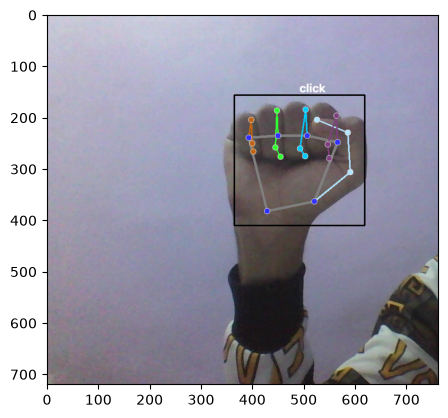

c:\Users\lotfi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


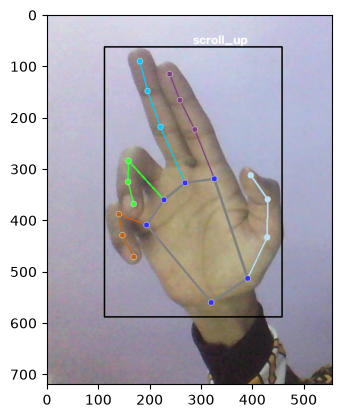

c:\Users\lotfi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


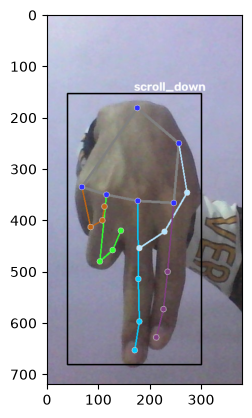

c:\Users\lotfi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


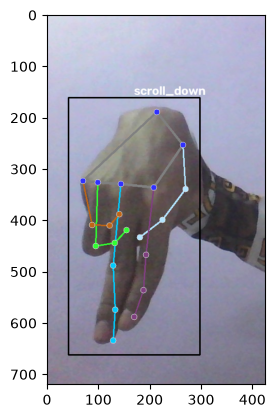

c:\Users\lotfi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


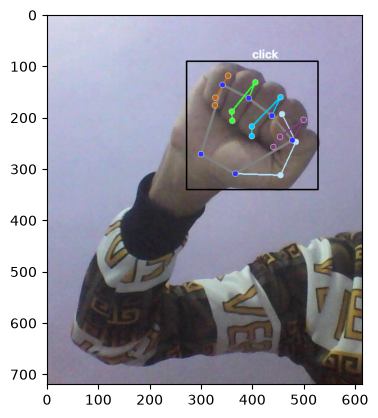

c:\Users\lotfi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


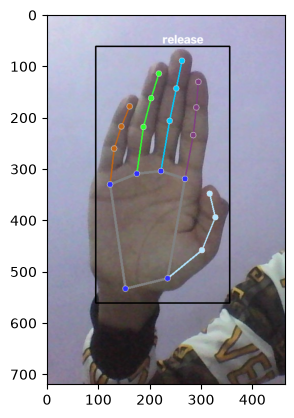

c:\Users\lotfi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


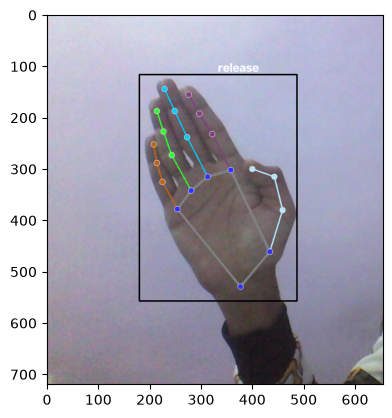

c:\Users\lotfi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


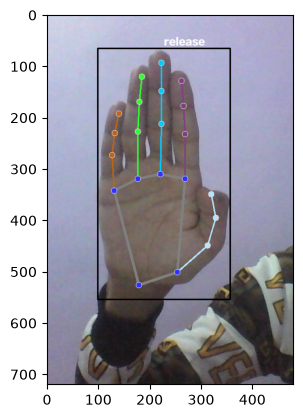

c:\Users\lotfi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


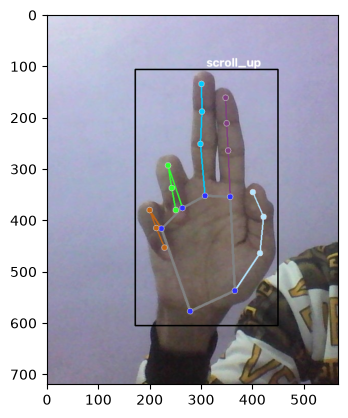

c:\Users\lotfi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


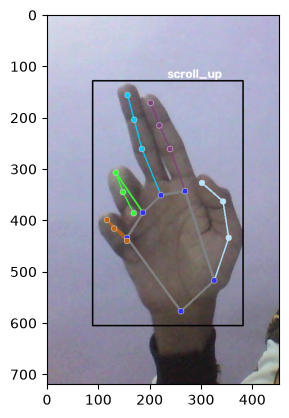

In [187]:
for path in samples_path:
    image = cv2.imread(path,cv2.IMREAD_COLOR_RGB)
    run(image,landmarker,model,idx_labels)


### And Finally we got our classifier, can easilly predict wich action we represent with our hand